# Part A: Customer Segmentation using RFM Analysis
## Automobile Parts Manufacturing — Transaction Data (3 Years)

**Objective:**  
An automobile parts manufacturing company has collected transaction data over 3 years. As a data science consultant, the goal is to:
1. Understand buying patterns of customers
2. Provide insights about different customer groups
3. Recommend customised marketing strategies for different segments using RFM (Recency, Frequency, Monetary) analysis

**Dataset:** `Sales_Data.xlsx`  
**Total Records:** 2,747 transactions | **Features:** 20 columns  
**Period Covered:** ~3 years of sales transactions  
**Unique Customers:** Multiple international customers across 19 countries

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style='whitegrid')

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load and Inspect the Data

In [2]:
# Load both sheets
df = pd.read_excel('Sales_Data.xlsx', sheet_name='Data')
data_dict = pd.read_excel('Sales_Data.xlsx', sheet_name='Data Dictionary ')

print(f'Shape of dataset: {df.shape}')
print(f'Columns: {list(df.columns)}')

Shape of dataset: (2747, 20)
Columns: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'DAYS_SINCE_LASTORDER', 'STATUS', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'CITY', 'POSTALCODE', 'COUNTRY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']


In [3]:
df.head(5)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,43155,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,43227,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,43282,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,43337,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,43401,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium


In [4]:
# Data Dictionary
data_dict.dropna(how='all').reset_index(drop=True)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,NaN,Column Name,Description
1,NaN,ORDERNUMBER,This column represents the unique identificati...
2,NaN,QUANTITYORDERED,It indicates the number of items ordered in ea...
3,NaN,PRICEEACH,This column specifies the price of each item i...
4,NaN,ORDERLINENUMBER,It represents the line number of each item wit...
5,NaN,SALES,This column denotes the total sales amount for...
6,NaN,ORDERDATE,It denotes the date on which the order was pla...
7,NaN,DAYS_SINCE_LASTORDER,This column represents the number of days that...
8,NaN,STATUS,"It indicates the status of the order, such as ..."
9,NaN,PRODUCTLINE,This column specifies the product line categor...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ORDERNUMBER           2747 non-null   int64  
 1   QUANTITYORDERED       2747 non-null   int64  
 2   PRICEEACH             2747 non-null   float64
 3   ORDERLINENUMBER       2747 non-null   int64  
 4   SALES                 2747 non-null   float64
 5   ORDERDATE             2747 non-null   int64  
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64  
 7   STATUS                2747 non-null   str    
 8   PRODUCTLINE           2747 non-null   str    
 9   MSRP                  2747 non-null   int64  
 10  PRODUCTCODE           2747 non-null   str    
 11  CUSTOMERNAME          2747 non-null   str    
 12  PHONE                 2747 non-null   str    
 13  ADDRESSLINE1          2747 non-null   str    
 14  CITY                  2747 non-null   str    
 15  POSTALCODE            2747 non-n

In [6]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,MSRP
count,2747.000000,2747.000000,2747.000000,2747.000000,2747.000000,2747.000000,2747.000000,2747.000000
mean,10259.761558,35.103021,101.098951,6.491081,3553.047583,43598.914088,1757.085912,100.691664
std,91.877521,9.762135,42.042548,4.230544,1838.953901,230.231295,819.280576,40.114802
min,10100.000000,6.000000,26.880000,1.000000,482.130000,43106.000000,42.000000,33.000000
25%,10181.000000,27.000000,68.745000,3.000000,2204.350000,43412.000000,1077.000000,68.000000
50%,10264.000000,35.000000,95.550000,6.000000,3184.800000,43640.000000,1761.000000,99.000000
75%,10334.500000,43.000000,127.100000,9.000000,4503.095000,43786.000000,2436.500000,124.000000
max,10425.000000,97.000000,252.870000,18.000000,14082.800000,43982.000000,3562.000000,214.000000


## 3. Data Cleaning & Preprocessing

In [7]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Check for duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
ORDERNUMBER             0
QUANTITYORDERED         0
PRICEEACH               0
ORDERLINENUMBER         0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
CUSTOMERNAME            0
PHONE                   0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
dtype: int64

Duplicate rows: 0


In [8]:
# ORDERDATE is stored as an integer (Excel serial date). Convert to datetime.
# Excel's epoch starts at 1899-12-30
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], unit='D', origin='1899-12-30')

# Extract time features
df['Year']    = df['ORDERDATE'].dt.year
df['Month']   = df['ORDERDATE'].dt.month
df['Quarter'] = df['ORDERDATE'].dt.quarter
df['Week']    = df['ORDERDATE'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['ORDERDATE'].dt.day_name()

print('Date range:', df['ORDERDATE'].min(), 'to', df['ORDERDATE'].max())
print('Years present:', sorted(df['Year'].unique()))

Date range: 2018-01-06 00:00:00 to 2020-05-31 00:00:00
Years present: [np.int32(2018), np.int32(2019), np.int32(2020)]


In [9]:
# Keep only 'Shipped' orders for revenue analysis (completed transactions)
print('Order Status distribution:')
print(df['STATUS'].value_counts())

df_shipped = df[df['STATUS'] == 'Shipped'].copy()
print(f'\nShipped orders: {len(df_shipped)} out of {len(df)}')

Order Status distribution:
STATUS
Shipped       2541
Cancelled       60
Resolved        47
On Hold         44
In Process      41
Disputed        14
Name: count, dtype: int64

Shipped orders: 2541 out of 2747


## 4. Exploratory Data Analysis (EDA)
### 4.1 Univariate Analysis

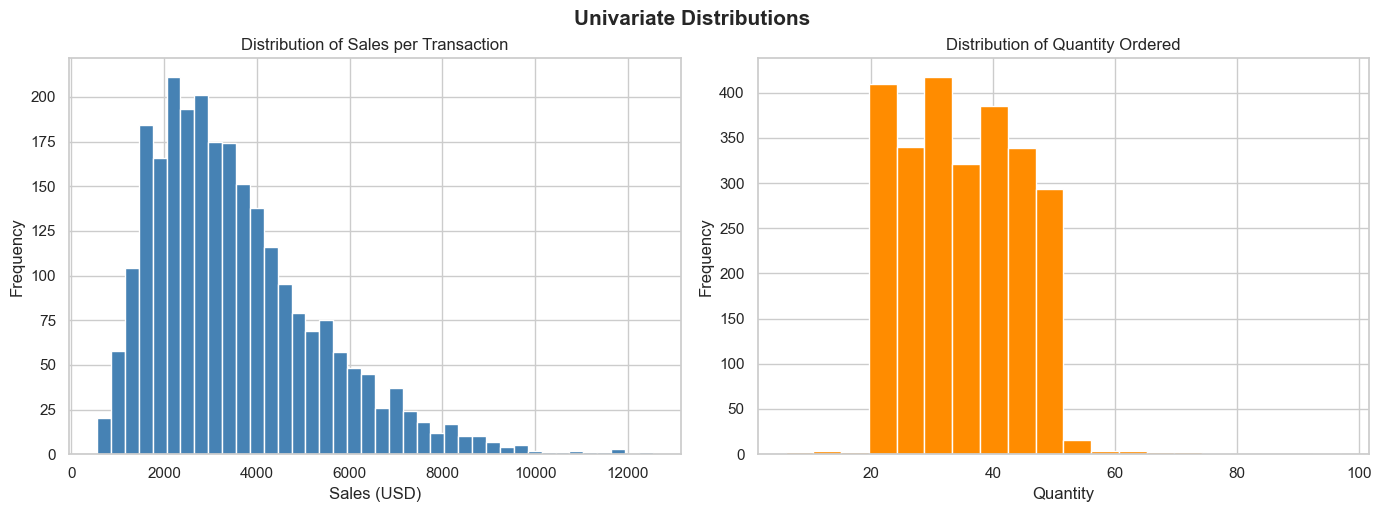

Average Sales per transaction: $3,549.43
Median Sales per transaction: $3,183.29


In [10]:
# Distribution of Sales (Revenue per transaction)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_shipped['SALES'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Sales per Transaction')
axes[0].set_xlabel('Sales (USD)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_shipped['QUANTITYORDERED'], bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Quantity Ordered')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Univariate Distributions', y=1.02, fontsize=15, fontweight='bold')
plt.show()

print(f"Average Sales per transaction: ${df_shipped['SALES'].mean():,.2f}")
print(f"Median Sales per transaction: ${df_shipped['SALES'].median():,.2f}")

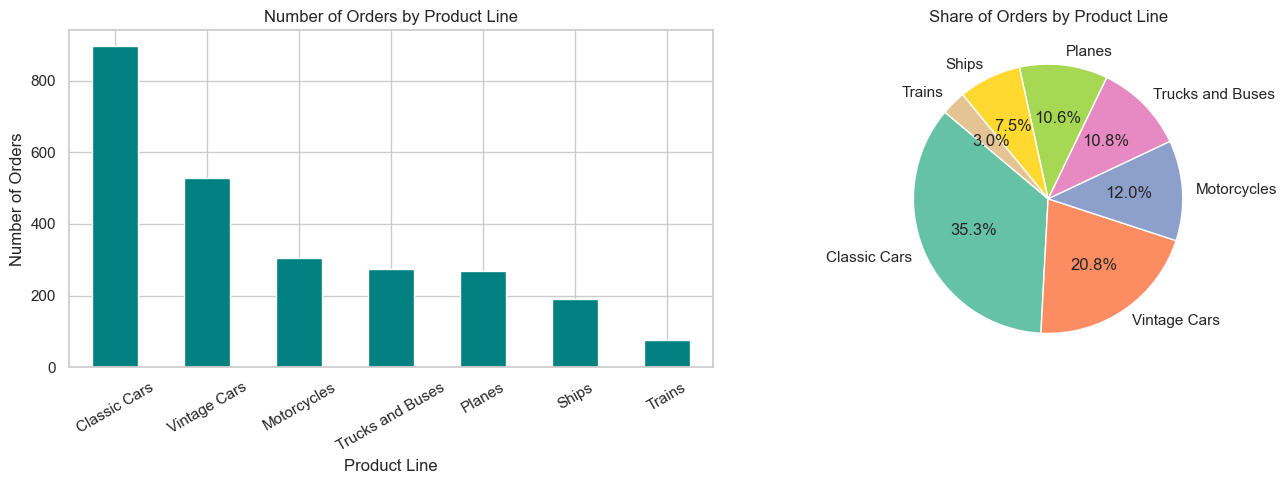


Inference: Classic Cars dominate the order volume, followed by Vintage Cars and Motorcycles.


In [11]:
# Product Line Distribution
pl_counts = df_shipped['PRODUCTLINE'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pl_counts.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Number of Orders by Product Line')
axes[0].set_xlabel('Product Line')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(pl_counts, labels=pl_counts.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(pl_counts)))
axes[1].set_title('Share of Orders by Product Line')

plt.tight_layout()
plt.show()

print('\nInference: Classic Cars dominate the order volume, followed by Vintage Cars and Motorcycles.')

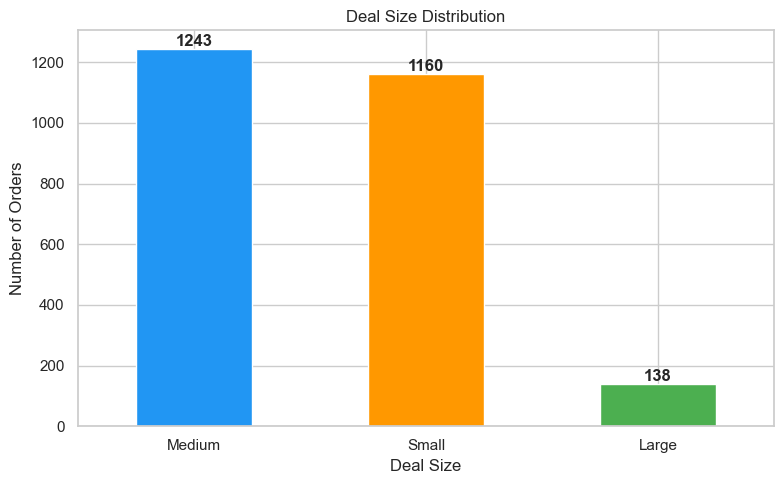


Inference: The majority of deals fall into the Small and Medium categories, with Large deals being rare but likely high-value.


In [12]:
# Deal Size Distribution
deal_counts = df_shipped['DEALSIZE'].value_counts()

plt.figure(figsize=(8, 5))
deal_counts.plot(kind='bar', color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
plt.title('Deal Size Distribution')
plt.xlabel('Deal Size')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
for i, v in enumerate(deal_counts):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInference: The majority of deals fall into the Small and Medium categories,'
      ' with Large deals being rare but likely high-value.')

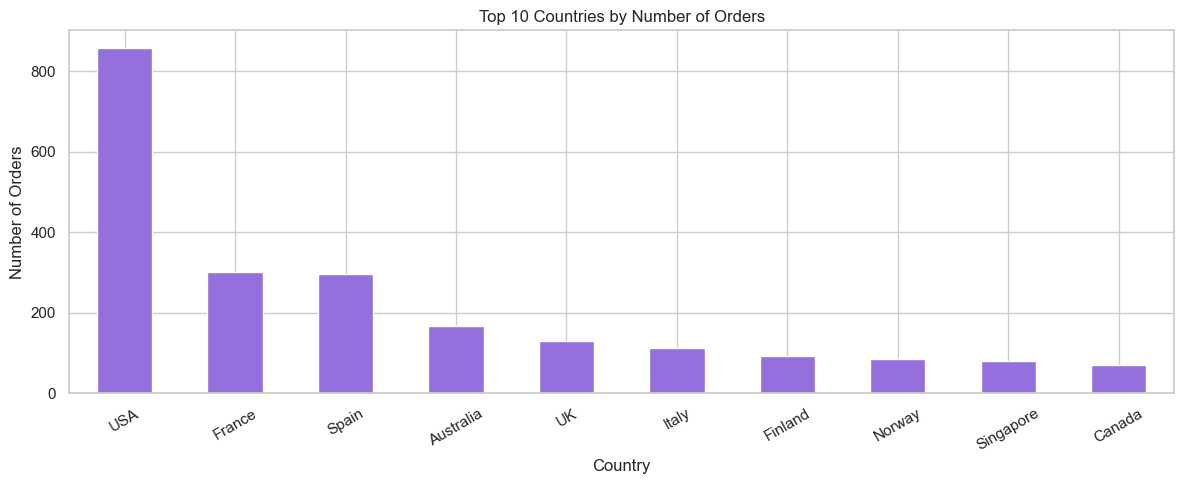


Inference: USA has the highest number of orders, followed by Spain and France.


In [13]:
# Top 10 Countries by Number of Orders
top_countries = df_shipped['COUNTRY'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Top 10 Countries by Number of Orders')
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nInference: USA has the highest number of orders, followed by Spain and France.')

### 4.2 Bivariate Analysis

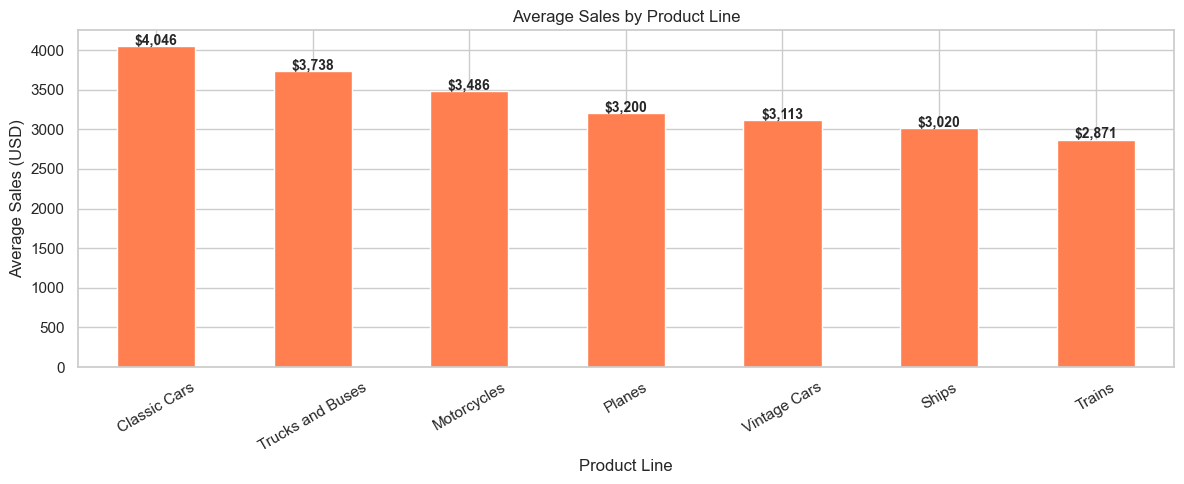


Inference: Trains and Ships generate the highest average sales per order, despite lower order volumes.


In [14]:
# Average Sales by Product Line
avg_sales_pl = df_shipped.groupby('PRODUCTLINE')['SALES'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
avg_sales_pl.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Average Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Average Sales (USD)')
plt.xticks(rotation=30)
for i, v in enumerate(avg_sales_pl):
    plt.text(i, v + 20, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInference: Trains and Ships generate the highest average sales per order,'
      ' despite lower order volumes.')

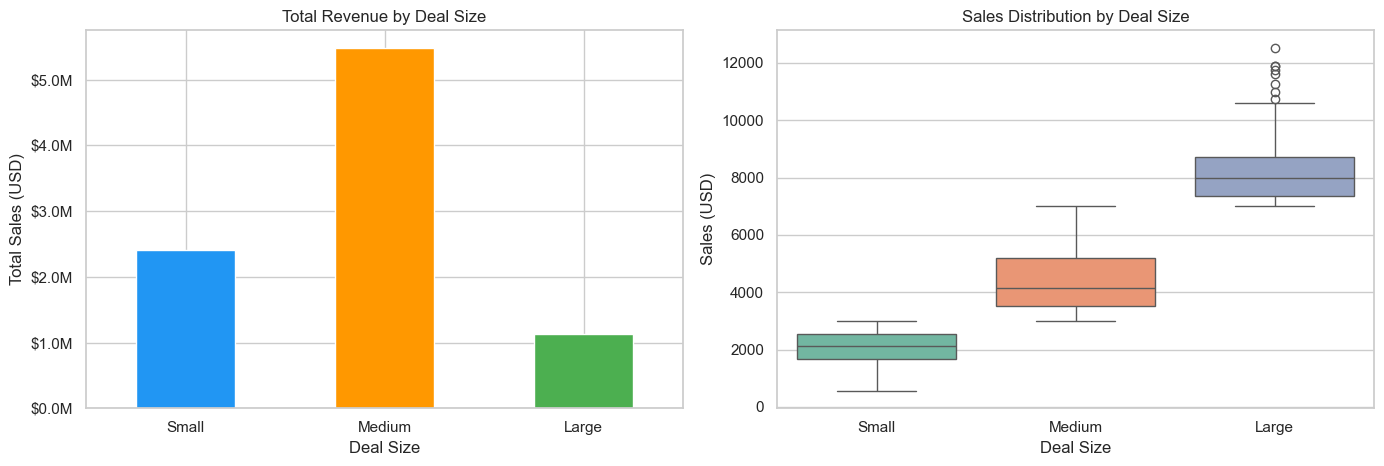


Inference: Medium deals generate more total revenue than Small or Large deals.


In [16]:
# Revenue by Deal Size
rev_deal = df_shipped.groupby('DEALSIZE')['SALES'].sum().reindex(['Small','Medium','Large'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rev_deal.plot(kind='bar', ax=axes[0], color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
axes[0].set_title('Total Revenue by Deal Size')
axes[0].set_xlabel('Deal Size')
axes[0].set_ylabel('Total Sales (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df_shipped, x='DEALSIZE', y='SALES', ax=axes[1],
            order=['Small','Medium','Large'], palette='Set2')
axes[1].set_title('Sales Distribution by Deal Size')
axes[1].set_xlabel('Deal Size')
axes[1].set_ylabel('Sales (USD)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('\nInference: Medium deals generate more total revenue than Small or Large deals.')

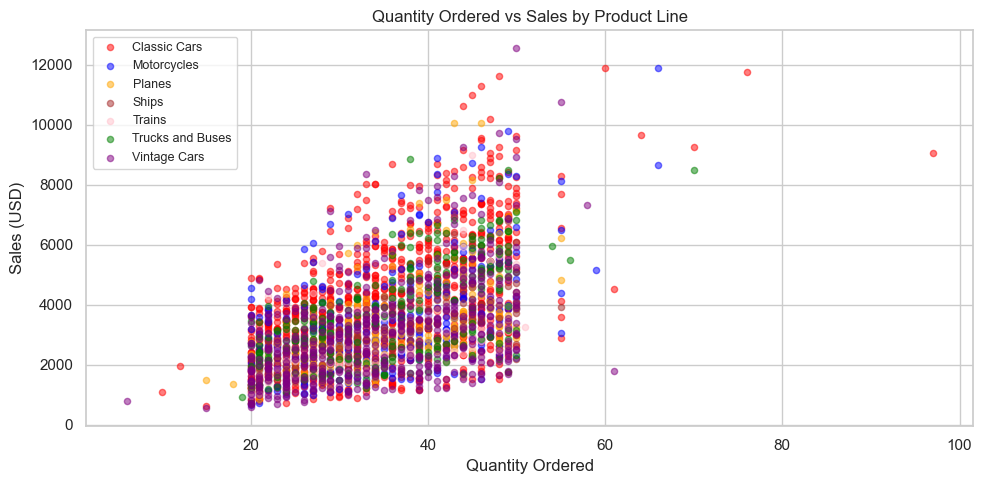


Correlation between Quantity and Sales: 0.538


In [17]:
# Quantity Ordered vs Sales (scatter)
plt.figure(figsize=(10, 5))
colors = {'Motorcycles':'blue','Classic Cars':'red','Trucks and Buses':'green',
          'Vintage Cars':'purple','Planes':'orange','Ships':'brown','Trains':'pink'}
for pl, group in df_shipped.groupby('PRODUCTLINE'):
    plt.scatter(group['QUANTITYORDERED'], group['SALES'], label=pl,
                alpha=0.5, s=20, color=colors.get(pl,'gray'))
plt.title('Quantity Ordered vs Sales by Product Line')
plt.xlabel('Quantity Ordered')
plt.ylabel('Sales (USD)')
plt.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

print(f"\nCorrelation between Quantity and Sales: {df_shipped['QUANTITYORDERED'].corr(df_shipped['SALES']):.3f}")

### 4.3 Trend Analysis — Weekly, Monthly, Quarterly, Yearly

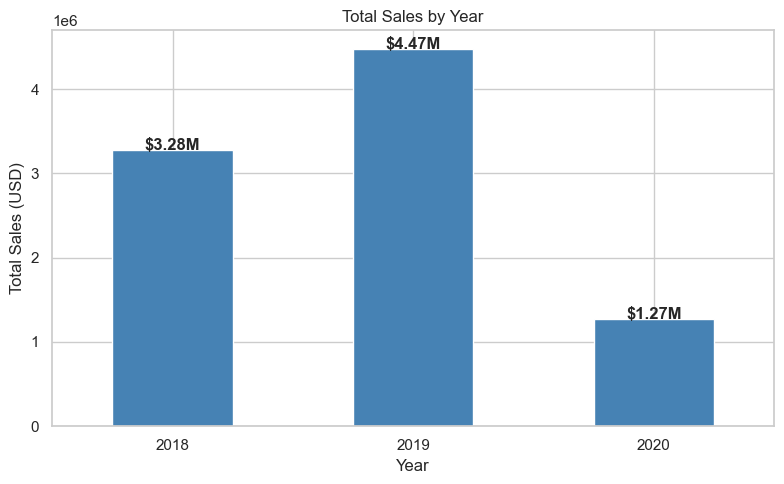


Inference: 2019 shows a partial year (peak before cutoff); 2018 was the highest full-year revenue year.


In [18]:
# Yearly Sales Trend
yearly = df_shipped.groupby('Year')['SALES'].sum()

plt.figure(figsize=(8, 5))
yearly.plot(kind='bar', color='steelblue', edgecolor='white', width=0.5)
for i, v in enumerate(yearly):
    plt.text(i, v + 5000, f'${v/1e6:.2f}M', ha='center', fontweight='bold')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales (USD)')
plt.xticks(rotation=0)
plt.yaxis if False else None
plt.tight_layout()
plt.show()

print('\nInference: 2019 shows a partial year (peak before cutoff); 2018 was the highest full-year revenue year.')

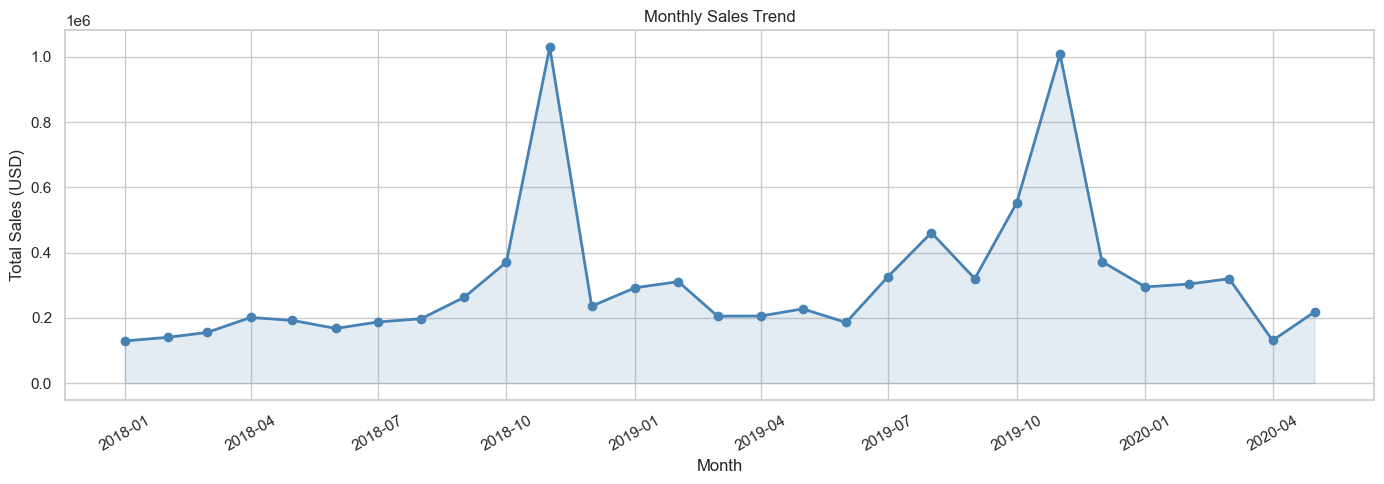


Inference: There are clear seasonal spikes, especially towards the end of each year (Q4).


In [19]:
# Monthly Sales Trend
monthly = df_shipped.groupby(['Year', 'Month'])['SALES'].sum().reset_index()
monthly['YearMonth'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))
monthly = monthly.sort_values('YearMonth')

plt.figure(figsize=(14, 5))
plt.plot(monthly['YearMonth'], monthly['SALES'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly['YearMonth'], monthly['SALES'], alpha=0.15, color='steelblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nInference: There are clear seasonal spikes, especially towards the end of each year (Q4).')

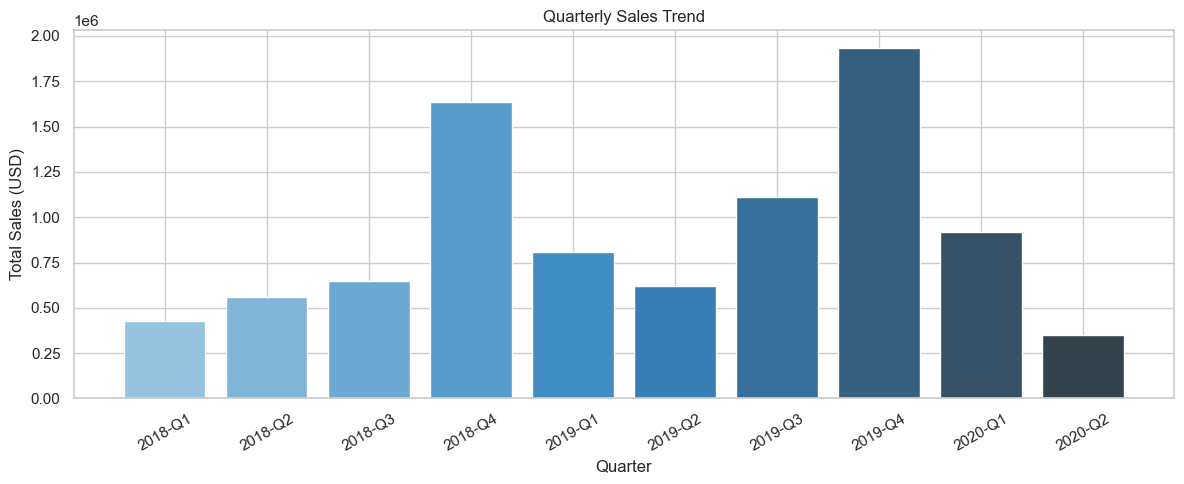


Inference: Q4 consistently records the highest sales across years — a holiday/end-of-year effect.


In [20]:
# Quarterly Sales Trend
quarterly = df_shipped.groupby(['Year','Quarter'])['SALES'].sum().reset_index()
quarterly['Label'] = quarterly['Year'].astype(str) + '-Q' + quarterly['Quarter'].astype(str)

plt.figure(figsize=(12, 5))
bars = plt.bar(quarterly['Label'], quarterly['SALES'],
               color=sns.color_palette('Blues_d', len(quarterly)), edgecolor='white')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nInference: Q4 consistently records the highest sales across years — a holiday/end-of-year effect.')

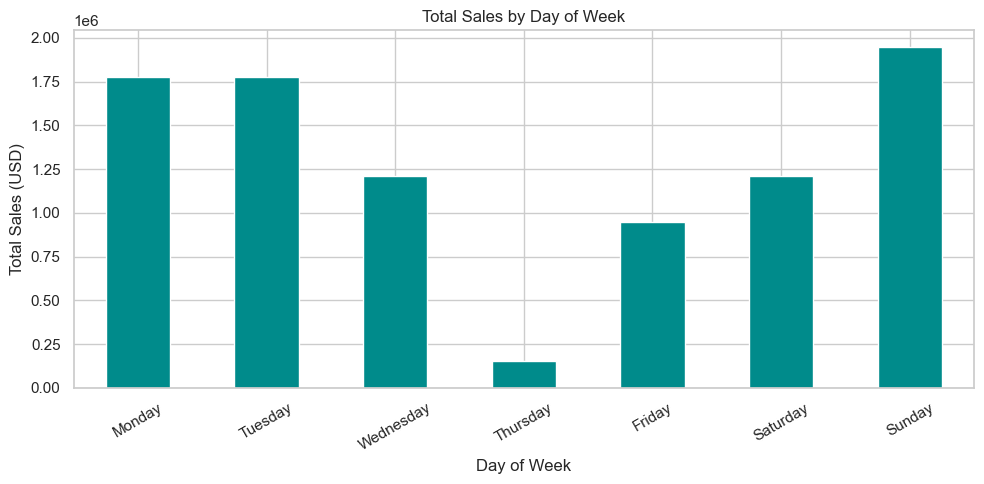


Inference: Mid-week days (Tuesday–Thursday) tend to generate more sales than Mondays or weekends.


In [21]:
# Sales by Day of Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales = df_shipped.groupby('DayOfWeek')['SALES'].sum().reindex(dow_order)

plt.figure(figsize=(10, 5))
dow_sales.plot(kind='bar', color='darkcyan', edgecolor='white')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\nInference: Mid-week days (Tuesday–Thursday) tend to generate more sales than Mondays or weekends.')

### 4.4 Multivariate Analysis

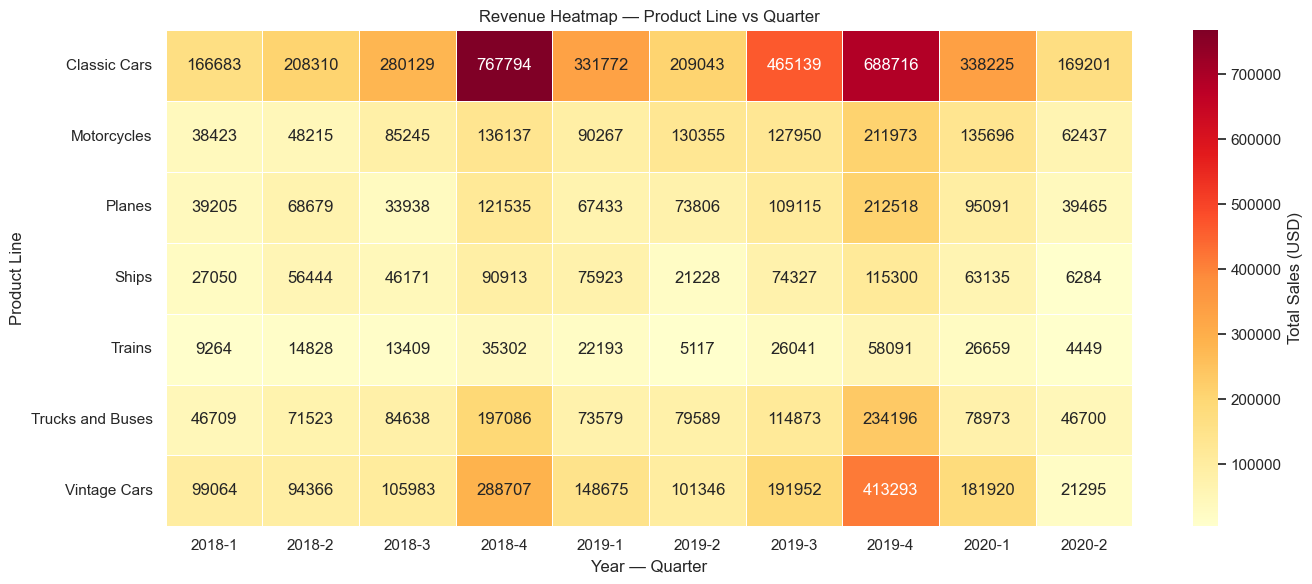


Inference: Classic Cars and Vintage Cars consistently lead revenue across all periods.


In [22]:
# Revenue Heatmap: Product Line x Year-Quarter
pivot = df_shipped.pivot_table(values='SALES', index='PRODUCTLINE',
                               columns=['Year','Quarter'], aggfunc='sum')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': 'Total Sales (USD)'})
plt.title('Revenue Heatmap — Product Line vs Quarter')
plt.ylabel('Product Line')
plt.xlabel('Year — Quarter')
plt.tight_layout()
plt.show()

print('\nInference: Classic Cars and Vintage Cars consistently lead revenue across all periods.')

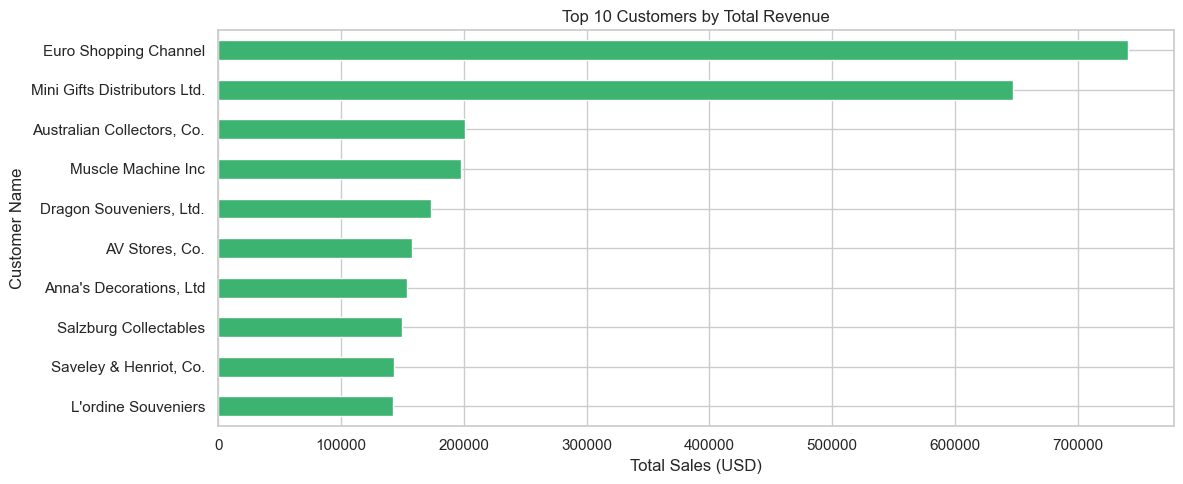

In [23]:
# Top 10 Customers by Revenue
top_customers = df_shipped.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_customers.plot(kind='barh', color='mediumseagreen', edgecolor='white')
plt.title('Top 10 Customers by Total Revenue')
plt.xlabel('Total Sales (USD)')
plt.ylabel('Customer Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

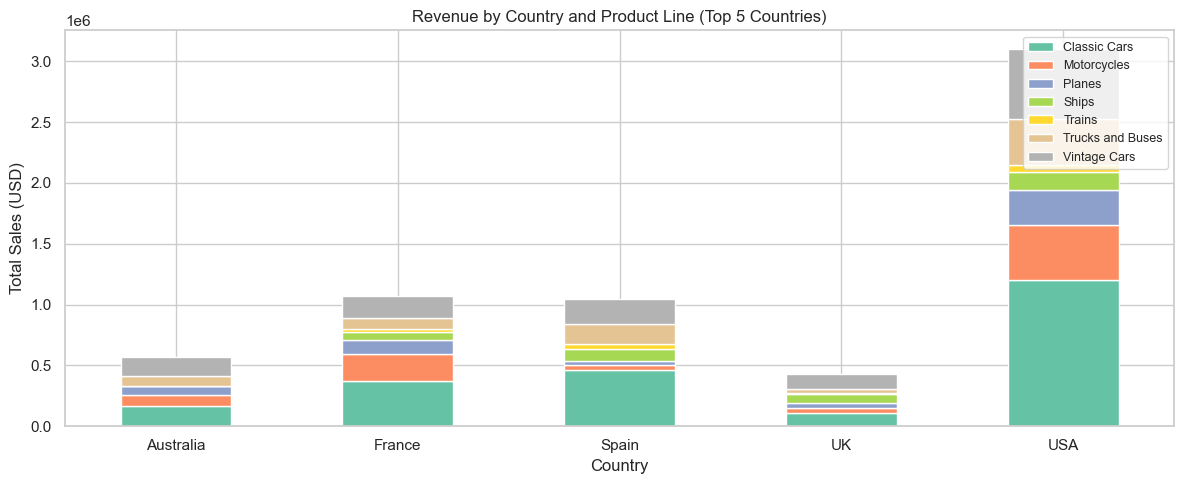

In [24]:
# Revenue by Country and Product Line (top 5 countries)
top5_countries = df_shipped['COUNTRY'].value_counts().head(5).index
df_top5 = df_shipped[df_shipped['COUNTRY'].isin(top5_countries)]

pivot2 = df_top5.pivot_table(values='SALES', index='COUNTRY',
                             columns='PRODUCTLINE', aggfunc='sum', fill_value=0)

pivot2.plot(kind='bar', stacked=True, figsize=(12, 5),
            colormap='Set2', edgecolor='white')
plt.title('Revenue by Country and Product Line (Top 5 Countries)')
plt.xlabel('Country')
plt.ylabel('Total Sales (USD)')
plt.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. RFM Analysis

### What is RFM?

**RFM** stands for **Recency, Frequency, and Monetary** — a proven customer segmentation framework widely used in CRM and direct marketing.

| Metric | Definition | What it tells us |
|--------|-----------|------------------|
| **Recency (R)** | Days since the customer's last purchase | How recently did the customer buy? |
| **Frequency (F)** | Total number of distinct orders placed | How often does the customer buy? |
| **Monetary (M)** | Total revenue generated from the customer | How much money does the customer spend? |

### Parameters and Assumptions
- **Reference date** (snapshot date): One day after the last transaction date in the dataset. This is because in practice, RFM is computed relative to "today".
- Only **Shipped** orders are used, as these represent confirmed completed revenue.
- Each unique `CUSTOMERNAME` is treated as a distinct customer entity.
- **Scoring**: Each RFM metric is divided into **4 quartile-based bins** (scores 1–4). For Recency, a *lower* number of days is better (score 4 = most recent).

In [25]:
# Reference date: day after last order in the dataset
reference_date = df_shipped['ORDERDATE'].max() + pd.Timedelta(days=1)
print(f'Reference (Snapshot) Date: {reference_date.date()}')

# Build RFM table
rfm = df_shipped.groupby('CUSTOMERNAME').agg(
    Recency   = ('ORDERDATE',   lambda x: (reference_date - x.max()).days),
    Frequency = ('ORDERNUMBER', 'nunique'),
    Monetary  = ('SALES',       'sum')
).reset_index()

print(f'\nTotal unique customers: {len(rfm)}')
rfm.head(10)

Reference (Snapshot) Date: 2020-05-18

Total unique customers: 89


,CUSTOMERNAME,Recency,Frequency,Monetary
0,"AV Stores, Co.",183,3,157807.81
1,Alpha Cognac,51,3,70488.44
2,Amica Models & Co.,252,2,94117.26
3,"Anna's Decorations, Ltd",70,4,153996.13
4,Atelier graphique,175,3,24179.96
5,"Australian Collectables, Ltd",321,2,50213.37
6,"Australian Collectors, Co.",171,5,200995.41
7,"Australian Gift Network, Co",106,3,59469.12
8,Auto Assoc. & Cie.,220,2,64834.32
9,Auto Canal Petit,41,3,93170.66


In [26]:
rfm.describe()

,Recency,Frequency,Monetary
count,89.000000,89.000000,89.000000
mean,195.101124,3.112360,101338.134157
std,126.852639,2.586847,98365.238408
min,1.000000,1.000000,9129.350000
25%,105.000000,2.000000,64834.320000
50%,184.000000,3.000000,85171.590000
75%,251.000000,3.000000,113961.150000
max,547.000000,22.000000,741512.500000


In [27]:
# Assign RFM Scores (1-4 quartile-based bins)
# Recency: lower days = better = higher score (hence labels reversed)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1, 2, 3, 4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print('RFM Scores assigned.')
rfm[['CUSTOMERNAME','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score','RFM_Total']].head(10)

RFM Scores assigned.


,CUSTOMERNAME,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,"AV Stores, Co.",183,3,157807.81,3,2,4,324,9
1,Alpha Cognac,51,3,70488.44,4,2,2,422,8
2,Amica Models & Co.,252,2,94117.26,1,1,3,113,5
3,"Anna's Decorations, Ltd",70,4,153996.13,4,4,4,444,12
4,Atelier graphique,175,3,24179.96,3,2,1,321,6
5,"Australian Collectables, Ltd",321,2,50213.37,1,1,1,111,3
6,"Australian Collectors, Co.",171,5,200995.41,3,4,4,344,11
7,"Australian Gift Network, Co",106,3,59469.12,3,2,1,321,6
8,Auto Assoc. & Cie.,220,2,64834.32,2,1,1,211,4
9,Auto Canal Petit,41,3,93170.66,4,2,3,423,9


In [28]:
# Segment customers into 4 groups based on RFM_Total
def assign_segment(score):
    if score >= 10:
        return 'Best Customers'
    elif score >= 7:
        return 'Loyal Customers'
    elif score >= 5:
        return 'At Risk / Verge of Churning'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm['RFM_Total'].apply(assign_segment)

print('Segment distribution:')
print(rfm['Segment'].value_counts())

Segment distribution:
Segment
Loyal Customers                33
Best Customers                 21
Lost Customers                 18
At Risk / Verge of Churning    17
Name: count, dtype: int64


In [29]:
# Segment Summary
seg_summary = rfm.groupby('Segment').agg(
    Count     = ('CUSTOMERNAME', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean'),
    Total_Revenue = ('Monetary',  'sum')
).round(2)

seg_summary

,Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
At Risk / Verge of Churning,17,231.71,2.18,66062.86,1123068.70
Best Customers,21,85.19,5.14,184600.72,3876615.09
Lost Customers,18,344.56,1.94,51223.31,922019.61
Loyal Customers,33,164.67,2.94,93860.32,3097390.54


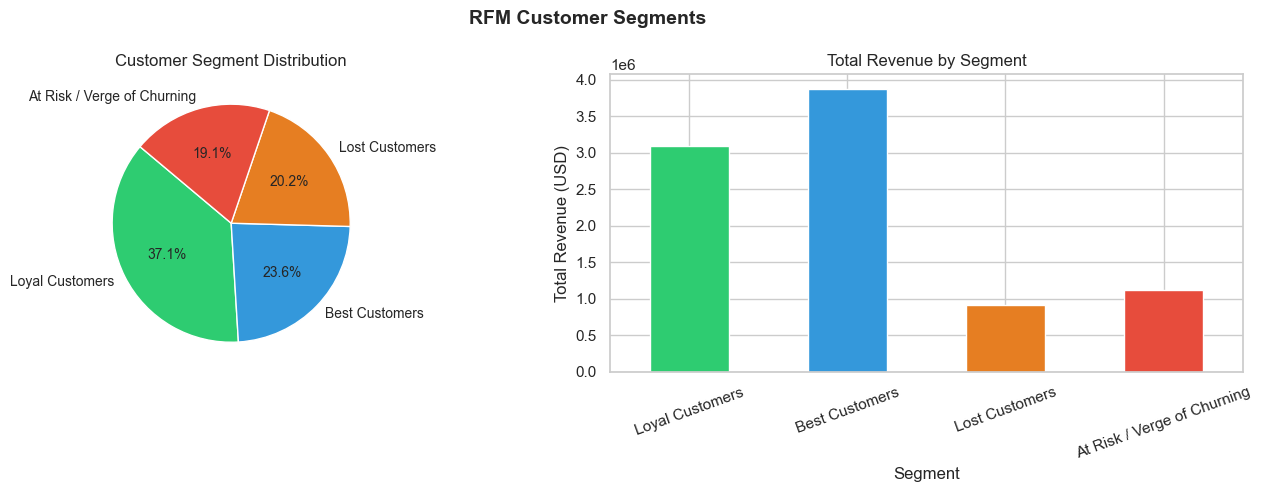

In [30]:
# Visualise Segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#e67e22','#e74c3c']

axes[0].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 10})
axes[0].set_title('Customer Segment Distribution')

seg_rev = rfm.groupby('Segment')['Monetary'].sum().reindex(seg_counts.index)
seg_rev.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Total Revenue by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Revenue (USD)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('RFM Customer Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

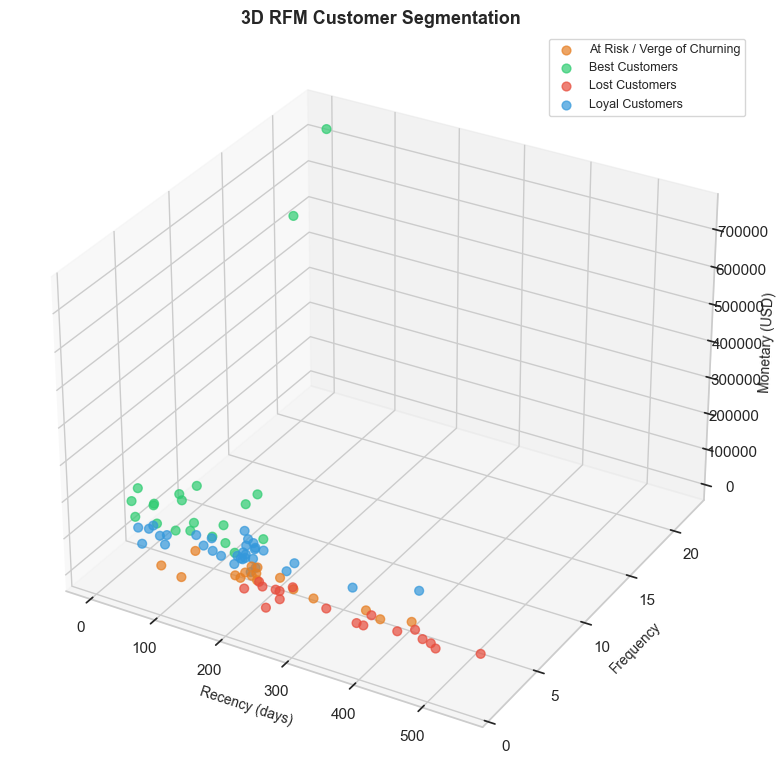

In [31]:
# 3D scatter: R vs F vs M coloured by Segment
from mpl_toolkits.mplot3d import Axes3D

seg_color_map = {
    'Best Customers': '#2ecc71',
    'Loyal Customers': '#3498db',
    'At Risk / Verge of Churning': '#e67e22',
    'Lost Customers': '#e74c3c'
}

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for seg, grp in rfm.groupby('Segment'):
    ax.scatter(grp['Recency'], grp['Frequency'], grp['Monetary'],
               label=seg, color=seg_color_map[seg], alpha=0.7, s=40)

ax.set_xlabel('Recency (days)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_zlabel('Monetary (USD)', fontsize=10)
ax.set_title('3D RFM Customer Segmentation', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Inferences from RFM Analysis
### 6.1 Best Customers (RFM Total Score ≥ 10)

In [32]:
best = rfm[rfm['Segment'] == 'Best Customers'].sort_values('RFM_Total', ascending=False)
print('Best Customers (Top 10):')
best[['CUSTOMERNAME','Recency','Frequency','Monetary','RFM_Total']].head(10)

Best Customers (Top 10):


,CUSTOMERNAME,Recency,Frequency,Monetary,RFM_Total
3,"Anna's Decorations, Ltd",70,4,153996.13,12
32,Euro Shopping Channel,15,22,741512.50,12
30,"Dragon Souveniers, Ltd.",77,5,172989.68,12
53,Mini Gifts Distributors Ltd.,56,16,647596.31,12
37,Handji Gifts& Co,25,4,115498.73,12
79,"Tokyo Collectables, Ltd",26,4,120562.74,12
67,Salzburg Collectables,1,4,149798.63,12
63,Reims Collectables,49,5,135042.94,12
6,"Australian Collectors, Co.",171,5,200995.41,11
81,"Toys of Finland, Co.",99,3,111250.38,11


**Characteristics:** These customers bought very recently, place many orders, and spend the most.  
**Strategy:** Offer VIP loyalty programmes, early access to new product lines, and premium personalised service to retain them.

### 6.2 Loyal Customers (RFM Total Score 7–9)

In [33]:
loyal = rfm[rfm['Segment'] == 'Loyal Customers'].sort_values('RFM_Total', ascending=False)
print('Loyal Customers (Top 10):')
loyal[['CUSTOMERNAME','Recency','Frequency','Monetary','RFM_Total']].head(10)

Loyal Customers (Top 10):


,CUSTOMERNAME,Recency,Frequency,Monetary,RFM_Total
0,"AV Stores, Co.",183,3,157807.81,9
9,Auto Canal Petit,41,3,93170.66,9
24,Cruz & Sons Co.,184,3,94015.73,9
45,Lyon Souveniers,62,3,78570.34,9
27,Diecast Classics Inc.,198,3,115971.34,9
42,"La Corne D'abondance, Co.",180,3,97203.68,9
44,Land of Toys Inc.,185,3,118711.78,9
52,Mini Creations Ltd.,132,3,108951.13,9
85,Vitachrome Inc.,195,3,88041.26,9
69,Scandinavian Gift Ideas,76,2,85548.41,9


**Characteristics:** Customers who order regularly and have decent spend, but not in the top tier.  
**Strategy:** Introduce tier-based rewards, volume discounts, and cross-sell complementary product lines to nudge them toward the Best Customers segment.

### 6.3 Customers at Risk / Verge of Churning (RFM Total Score 5–6)

In [34]:
at_risk = rfm[rfm['Segment'] == 'At Risk / Verge of Churning'].sort_values('Recency', ascending=False)
print('At Risk Customers (Top 10 — sorted by most days since last order):')
at_risk[['CUSTOMERNAME','Recency','Frequency','Monetary','RFM_Total']].head(10)

At Risk Customers (Top 10 — sorted by most days since last order):


,CUSTOMERNAME,Recency,Frequency,Monetary,RFM_Total
21,Collectable Mini Designs Co.,447,2,87489.23,5
59,Osaka Souveniers Co.,401,2,67605.07,5
75,Super Scale Inc.,380,2,79472.07,5
61,Petit Auto,302,2,66560.57,5
65,"Royal Canadian Collectables, Ltd.",272,2,74634.85,5
2,Amica Models & Co.,252,2,94117.26,5
47,Marta's Replicas Co.,218,2,103080.38,6
18,"Classic Gift Ideas, Inc",217,2,67506.97,5
51,Mini Classics,216,2,85555.99,6
17,Canadian Gift Exchange Network,209,2,75238.92,5


**Characteristics:** Previously active customers who have not ordered recently. They may be switching to competitors.  
**Strategy:** Send targeted re-engagement campaigns, personalised discount coupons, and win-back emails referencing their past purchases.

### 6.4 Lost Customers (RFM Total Score ≤ 4)

In [35]:
lost = rfm[rfm['Segment'] == 'Lost Customers'].sort_values('Recency', ascending=False)
print('Lost Customers (Top 10):')
lost[['CUSTOMERNAME','Recency','Frequency','Monetary','RFM_Total']].head(10)

Lost Customers (Top 10):


,CUSTOMERNAME,Recency,Frequency,Monetary,RFM_Total
82,Toys4GrownUps.com,547,2,60288.60,4
29,"Double Decker Gift Stores, Ltd",482,2,36019.04,3
87,West Coast Collectables Co.,475,2,46084.64,4
70,Signal Collectibles Ltd.,463,2,50218.51,4
25,Daedalus Designs Imports,452,2,69052.41,4
15,CAF Imports,426,2,49642.05,3
28,Diecast Collectables,388,2,70859.78,4
16,Cambridge Collectables Co.,376,2,36163.62,3
77,Tekni Collectables Inc.,366,2,36709.19,4
5,"Australian Collectables, Ltd",321,2,50213.37,3


**Characteristics:** Customers who bought long ago, infrequently, and spent the least. They are likely churned.  
**Strategy:** Run low-cost reactivation campaigns (e.g., 'We miss you' emails with a strong incentive), or consider deprioritising marketing spend on this group.

## 7. Export RFM Results

In [37]:
rfm.to_csv('RFM_Segmentation_Results.csv', index=False)
print('RFM results exported to RFM_Segmentation_Results.csv')
rfm.head()

RFM results exported to RFM_Segmentation_Results.csv


,CUSTOMERNAME,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,"AV Stores, Co.",183,3,157807.81,3,2,4,324,9,Loyal Customers
1,Alpha Cognac,51,3,70488.44,4,2,2,422,8,Loyal Customers
2,Amica Models & Co.,252,2,94117.26,1,1,3,113,5,At Risk / Verge of Churning
3,"Anna's Decorations, Ltd",70,4,153996.13,4,4,4,444,12,Best Customers
4,Atelier graphique,175,3,24179.96,3,2,1,321,6,At Risk / Verge of Churning


## 8. Summary & Marketing Recommendations

| Segment | Count | Avg Recency (days) | Avg Frequency | Avg Spend (USD) | Strategy |
|---------|-------|--------------------|---------------|-----------------|----------|
| **Best Customers** | Top quartile | Low | High | High | VIP rewards, early access, personal account manager |
| **Loyal Customers** | Second tier | Moderate | Moderate | Moderate | Tier upgrades, cross-sell, volume discounts |
| **At Risk** | Third tier | High | Low–Moderate | Low–Moderate | Re-engagement campaigns, personalised win-back offers |
| **Lost Customers** | Bottom tier | Very High | Very Low | Very Low | 'We miss you' campaigns, minimal marketing spend |

**Key Insights:**
1. Classic Cars and Vintage Cars dominate both order volume and revenue — prioritise stock and service for these lines.
2. Q4 shows strong seasonal spikes — plan promotions and inventory accordingly.
3. The USA is the single largest market — localised campaigns for the US audience will have the highest ROI.
4. Medium deal size generates the most total revenue — incentivise customers hovering on Small deals to upsize.
5. A small group of Best Customers is likely responsible for a disproportionately large share of revenue — protect them with dedicated relationship management.